# <br><center>**Statistical Bootstrapping – Penguins**

In [1]:
import gc; gc.enable()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.style.use("dark_background")
plt.rcParams.update({
    "figure.figsize": (14,8),
    "font.size": 14,
    "axes.grid": True,
    "grid.alpha": 0.2
})
import seaborn as sns
from tqdm.notebook import tqdm

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score 
import scipy.stats as stats
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

print("setup done!")

setup done!


In [2]:
# load data
df = sns.load_dataset("penguins").dropna()

print(f"shape: {df.shape}")
df.head()

shape: (333, 7)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [3]:
# how much bigger are male penguins than female penguins
def delta_mass(df):
    return df.query("sex == 'Male'").body_mass_g.mean() \
        - df.query("sex == 'Female'").body_mass_g.mean()

delta = delta_mass(df)
print(f"Difference: {delta:.2f}g")

Difference: 683.41g


## <center>**What now?**
<div style="display: flex; justify-content: center; font-size: 1rem">
If this was the quantity we were interested in, we could report this alone. <br><br>
Instead, we are going to use bootstrapping to create a 95% confidence interval!
</div>

In [4]:
n = df.shape[0]

for boot in range(5):
    df_boot = df.sample(n, replace=True)
    delta_boot = delta_mass(df_boot)
    print(f"Boot {boot+1}: Difference = {delta_mass(df_boot):.2f}g")

Boot 1: Difference = 566.22g
Boot 2: Difference = 698.79g
Boot 3: Difference = 632.15g
Boot 4: Difference = 629.65g
Boot 5: Difference = 800.10g


<div style="display: flex; justify-content: center; font-size: 1rem">
Treat these as random variables X1 , . . . , Xm for m bootstraps
</div>

bootstrapping statistic:   0%|          | 0/1000 [00:00<?, ?it/s]

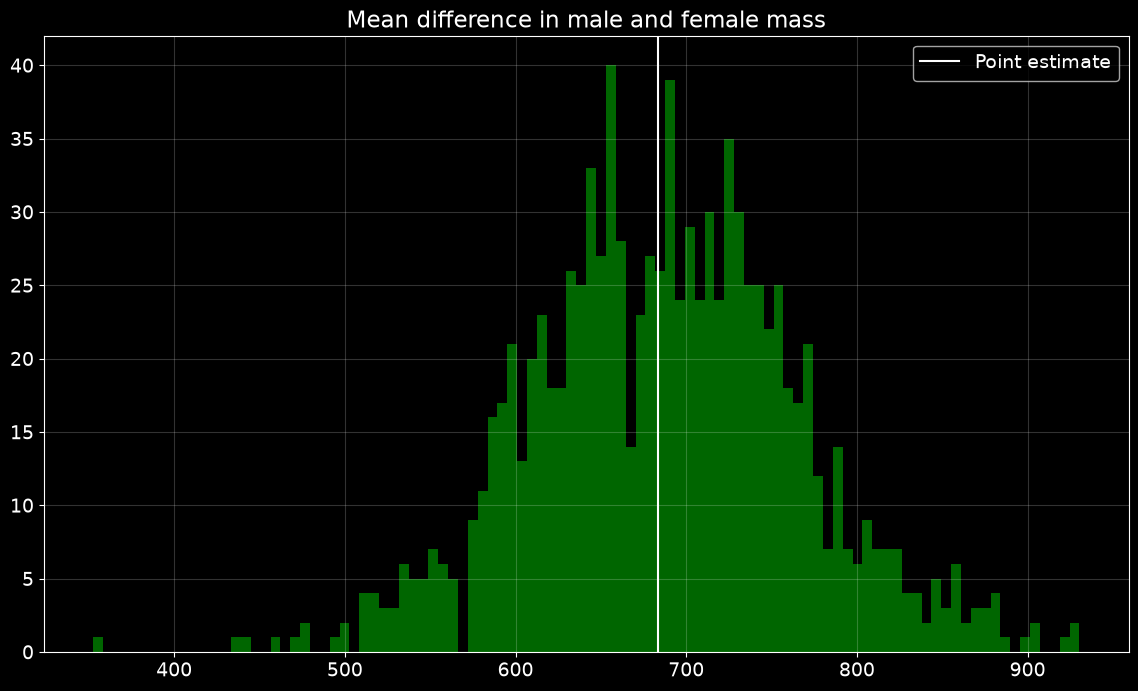

In [5]:
m = 1000
boot_statistics = np.zeros(m)

for boot in tqdm(range(m), desc="bootstrapping statistic", leave=False):
    df_boot = df.sample(n, replace=True, random_state=67*(boot+41))
    boot_statistics[boot] = delta_mass(df_boot)

plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

In [6]:
# confidence interval
theta_mean = np.mean(boot_statistics)
theta_std = np.std(boot_statistics)

z_coeff = 2.33 # 98% confidence interval
error_margin = z_coeff * theta_std / np.sqrt(m)

theta_lower = theta_mean - error_margin
theta_upper = theta_mean + error_margin

print(f"98% CI: [{theta_lower:.4f}, {theta_upper:.4f}]")

98% CI: [681.8286, 693.4688]


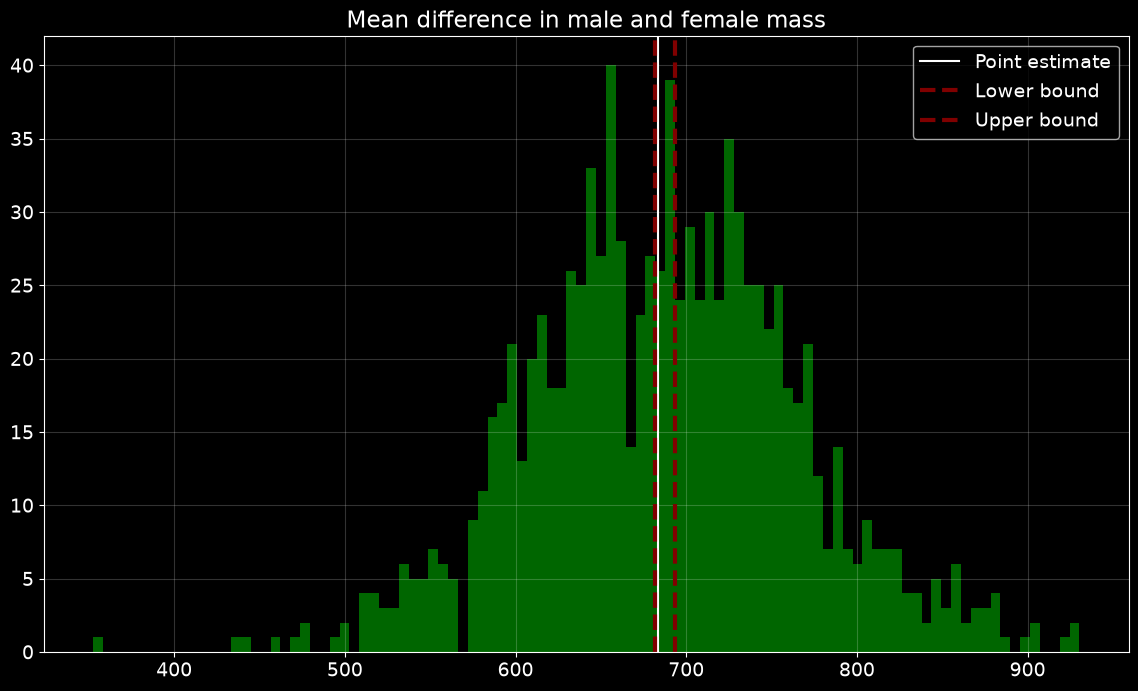

In [7]:
plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.axvline(theta_lower, linestyle="--", linewidth=3, color="maroon", label="Lower bound")
plt.axvline(theta_upper, linestyle="--", linewidth=3, color="maroon", label="Upper bound")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

bootstrapping statistic:   0%|          | 0/10000 [00:00<?, ?it/s]

98% CI: [682.1236, 685.8688]


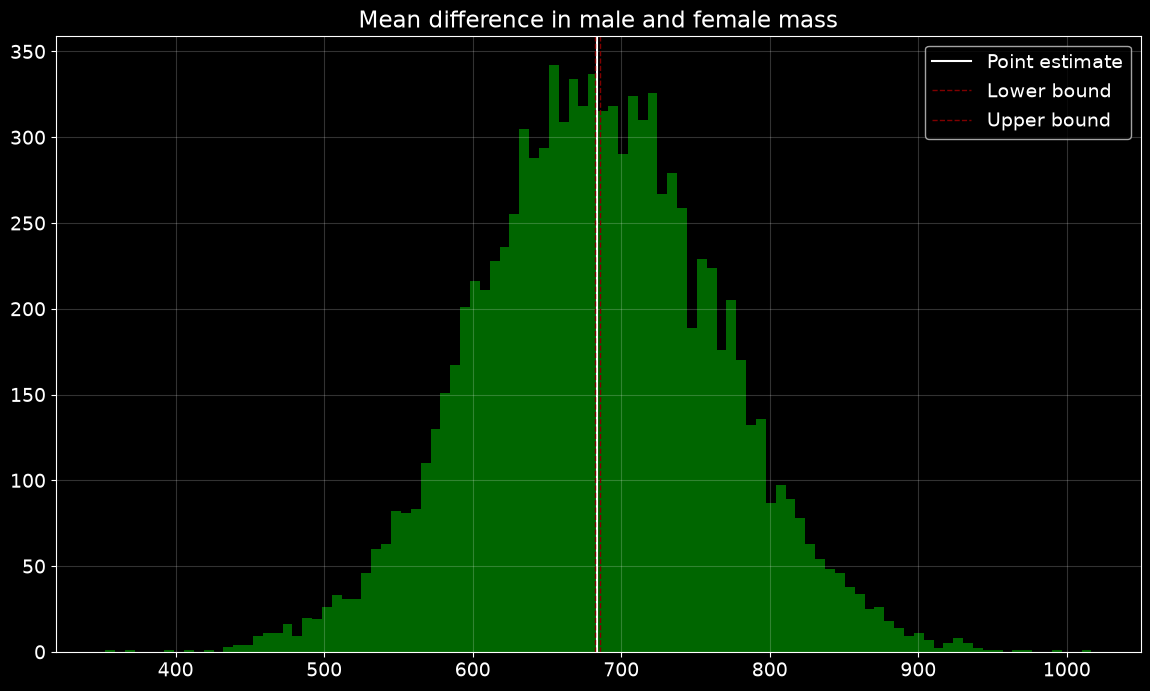

In [8]:
# 10.000 bootstraps
m = 10_000
boot_statistics = np.zeros(m)

for boot in tqdm(range(m), desc="bootstrapping statistic", leave=False):
    df_boot = df.sample(n, replace=True, random_state=67*(boot+41))
    boot_statistics[boot] = delta_mass(df_boot)

theta_mean = np.mean(boot_statistics)
theta_std = np.std(boot_statistics)

z_coeff = 2.33 # 98% confidence interval
error_margin = z_coeff * theta_std / np.sqrt(m)

theta_lower = theta_mean - error_margin
theta_upper = theta_mean + error_margin

print(f"98% CI: [{theta_lower:.4f}, {theta_upper:.4f}]")

plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.axvline(theta_lower, linestyle="--", linewidth=1, color="maroon", label="Lower bound")
plt.axvline(theta_upper, linestyle="--", linewidth=1, color="maroon", label="Upper bound")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

## <br><center>**Practical use for machine learning**
<div style="display: flex; justify-content: center; font-size: 1rem; width:90%; margin: auto;">
In ML, we use bootstrapping to produce confidence intervals on evaluation metrics. <br><br>
Consider an evaluation set. Predicting on this with your model and computing its loss corresponds to a point estimate. <br><br>
Doing this many times over different samples of your evaluation set, you will get a similar distribution, after which you can compute a confidence interval for that model over that evaluation set.
</div>

In [9]:
# data preprocessing
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


In [10]:
text_cols = "species island sex".split()

for tc in text_cols:
    print(f"col: {tc}\tclasses:   {' '.join(list(df[tc].unique()))}")

col: species	classes:   Adelie Chinstrap Gentoo
col: island	classes:   Torgersen Biscoe Dream
col: sex	classes:   Male Female


In [11]:
# species2idx = {"Adelie":0, "Chinstrap":1, "Gentoo":2}
# df["species"] = df["species"].map(species2idx)

# island2idx = {"Torgersen":0, "Biscoe":1, "Dream":2}
# df["island"] = df["island"].map(island2idx)

sex2idx = {"Male":0, "Female":1}
df["sex"] = df["sex"].map(sex2idx)

df

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,0
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,1
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,1
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,1
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,0
...,...,...,...,...,...,...,...
338,Gentoo,Biscoe,47.2,13.7,214.0,4925.0,1
340,Gentoo,Biscoe,46.8,14.3,215.0,4850.0,1
341,Gentoo,Biscoe,50.4,15.7,222.0,5750.0,0
342,Gentoo,Biscoe,45.2,14.8,212.0,5200.0,1


In [12]:
df = pd.get_dummies(df, prefix='', prefix_sep='', drop_first=True, dtype=int); df

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,Chinstrap,Gentoo,Dream,Torgersen
0,39.1,18.7,181.0,3750.0,0,0,0,0,1
1,39.5,17.4,186.0,3800.0,1,0,0,0,1
2,40.3,18.0,195.0,3250.0,1,0,0,0,1
4,36.7,19.3,193.0,3450.0,1,0,0,0,1
5,39.3,20.6,190.0,3650.0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...
338,47.2,13.7,214.0,4925.0,1,0,1,0,0
340,46.8,14.3,215.0,4850.0,1,0,1,0,0
341,50.4,15.7,222.0,5750.0,0,0,1,0,0
342,45.2,14.8,212.0,5200.0,1,0,1,0,0


In [13]:
features = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'Chinstrap', 'Gentoo', 'Dream', 'Torgersen']
target = "sex"

df_train, df_test = train_test_split(df, test_size=0.25, random_state=67)
x_train, y_train = df_train[features], df_train[target]
x_test, y_test = df_test[features], df_test[target]

print(f"\t\tTrain/Test sizes:\n\t{x_train.shape}, {y_train.shape}, {x_test.shape}, {y_test.shape}\n")

xgb = XGBClassifier(random_state=67)
lgbm = LGBMClassifier(random_state=67, verbose=-1)

xgb.fit(x_train, y_train)
lgbm.fit(x_train, y_train)

y_pred1 = xgb.predict(x_test)
y_pred2 = lgbm.predict(x_test)

df_test["pred1"] = y_pred1
df_test["pred2"] = y_pred2

acc1 = accuracy_score(y_test, y_pred1)
acc2 = accuracy_score(y_test, y_pred2)
f11 = f1_score(y_test, y_pred1)
f12 = f1_score(y_test, y_pred2)
delta = f11 - f12

print(f"\t\tPoint estimates:\n")
print(f"\tXgboost; {acc1:.4f}, Lightgbm; {acc2:.4f}\t\t Accuracy")
print(f"\tXgboost; {f11:.4f}, Lightgbm; {f12:.4f}\t\t F1 Score")

		Train/Test sizes:
	(249, 8), (249,), (84, 8), (84,)

		Point estimates:

	Xgboost; 0.8929, Lightgbm; 0.8929		 Accuracy
	Xgboost; 0.8889, Lightgbm; 0.8861		 F1 Score


bootstrapping model A/B testing:   0%|          | 0/10000 [00:00<?, ?it/s]

98% CI: [0.0023, 0.0036]


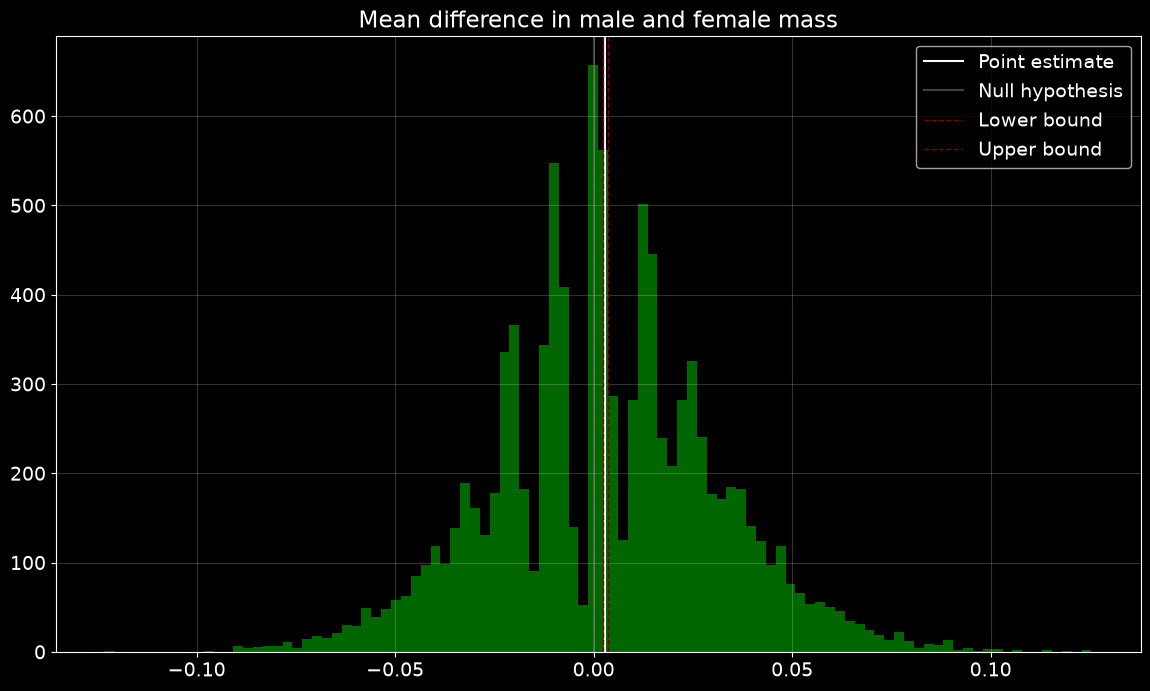

In [14]:
# bootstrapping
m = 10_000
n = x_test.shape[0]

boot_statistics = np.zeros(m)
for boot in tqdm(range(m), desc="bootstrapping model A/B testing"):
    df_sample = df_test.sample(n=n, replace=True)
    x_sample = df_sample[features]
    y_sample = df_sample[target]

    y_pred1 = xgb.predict(x_sample)
    y_pred2 = lgbm.predict(x_sample)

    f11 = f1_score(y_sample, y_pred1)
    f12 = f1_score(y_sample, y_pred2)

    boot_statistics[boot] = f11 - f12

theta_mean = np.mean(boot_statistics)
theta_std = np.std(boot_statistics)

z_coeff = 2.33 # 98% confidence interval
error_margin = z_coeff * theta_std / np.sqrt(m)

theta_lower = theta_mean - error_margin
theta_upper = theta_mean + error_margin

print(f"98% CI: [{theta_lower:.4f}, {theta_upper:.4f}]")

plt.hist(boot_statistics, bins=100, color="green", alpha=0.8)
plt.axvline(delta, label="Point estimate")
plt.axvline(0, color="grey", alpha=0.5, label="Null hypothesis")
plt.axvline(theta_lower, linestyle="--", linewidth=1, color="maroon", label="Lower bound")
plt.axvline(theta_upper, linestyle="--", linewidth=1, color="maroon", label="Upper bound")
plt.title("Mean difference in male and female mass")
plt.legend(); plt.show()

## <br><center>**Statistical Interpretation**
<div style="display: flex; justify-content: center; font-size: 1rem; width:90%; margin: auto;">
As our confidence interval for significance level alpha = 0.02 does not contain mu0 = 0, we can confirm that our results are statistically significant, and specifically, the xgboost classifier outperforms the lightgbm classifier. <br><br>
Furthermore, bootstrapping is more robust than the paired t-test, as it doesn't make any assumptions on the data distribution.
</div>